In [ ]:
from keras.models import Sequential
from keras.layers import Dense
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics
from matplotlib import pyplot as plt


In [2]:
model = Sequential()
model.add(Dense(20, input_dim= 5, activation= 'relu'))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer="adam", metrics=["mean_squared_error"])

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141 (564.00 B)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# from keras_visualizer import visualizer
# visualizer(model, file_name="model_DL", file_format="png")

In [5]:
df = pd.read_csv('co2.csv')
df.head(10)

,engine,cylandr,fuelcity,fuelwy,fuelcomb,out1
0,2.0,4,9.9,6.7,8.5,196
1,2.4,4,11.2,7.7,9.6,221
2,1.5,4,6.0,5.8,5.9,136
3,3.5,6,12.7,9.1,11.1,255
4,3.5,6,12.1,8.7,10.6,244
5,3.5,6,11.9,7.7,10.0,230
6,3.5,6,11.8,8.1,10.1,232
7,3.7,6,12.8,9.0,11.1,255
8,3.7,6,13.4,9.5,11.6,267
9,2.4,4,10.6,7.5,9.2,212


In [6]:
df.describe()

,engine,cylandr,fuelcity,fuelwy,fuelcomb,out1
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,522.000000


In [7]:
X = df.drop('out1',axis=1)
y = df.out1

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [10]:
h = model.fit(X_train, y_train, epochs=500)

Epoch 1/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 62683.4336 - mean_squared_error: 62683.4336
Epoch 2/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 46257.3359 - mean_squared_error: 46257.3359
Epoch 3/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 23874.8066 - mean_squared_error: 23874.8066
Epoch 4/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7816.3979 - mean_squared_error: 7816.3979  
Epoch 5/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1759.5890 - mean_squared_error: 1759.5890
Epoch 6/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 638.3290 - mean_squared_error: 638.3290
Epoch 7/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 537.6959 - mean_squared_error: 537.6959
Epoch 8/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 533.1373 - mean_squared_error: 533.1373
Epoch 9/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 532.5021 - mean_squared_error: 532.5021
Epoch 10/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 531.4885 - 

In [12]:
y_pred = model.predict(X_test)
y_pred

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[257.7376 ],
       [257.7376 ],
       [318.36392],
       ...,
       [230.82922],
       [314.35202],
       [245.70633]], dtype=float32)

In [13]:
y_test

2252    257
1137    253
5657    329
2323    238
4793    260
       ... 
5721    265
4902    201
153     228
2415    313
2808    248
Name: out1, Length: 1477, dtype: int64

In [27]:
print("metrics.mean_squared_error= ", metrics.mean_squared_error(y_test, y_pred))
print("mean_squared_error= ", h.history['loss'][-1])

metrics.mean_squared_error=  217.24666800820717
mean_squared_error=  212.16390991210938


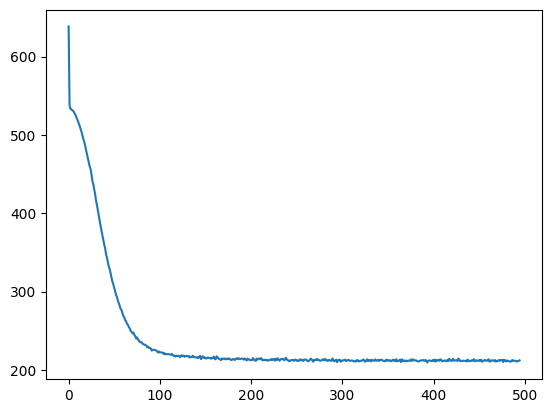

In [21]:
er=h.history['loss']
er=er[5:]
plt.close()
plt.plot(er)
plt.show()